Loaded 3,801 rows | Fox%: 52.62%
Embeddings shape: (3801, 384)
Temporal   — Train: 3,058 | Test: 743
             Test date range: 2024-09-27 -> 2026-04-07
Stratified — Train: 3,040 | Test: 761

Fusion feature shape: (3040, 391)

Fitting SVM (stratified)...
Fitting SVM (temporal)...
Fitting XGBoost (stratified)...


/Users/rohankrishnan/Documents/GitHub/cis-5190-news/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:34:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fitting XGBoost (temporal)...


/Users/rohankrishnan/Documents/GitHub/cis-5190-news/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:34:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



── Results ─────────────────────────────────────────────────
  MiniLM + style + SVM (stratified): 0.8147
  MiniLM + style + SVM (time split): 0.7699
  SVM stratified/temporal gap:       0.0449
  MiniLM + style + XGB (stratified): 0.7937
  MiniLM + style + XGB (time split): 0.7631
  XGB stratified/temporal gap:       0.0306


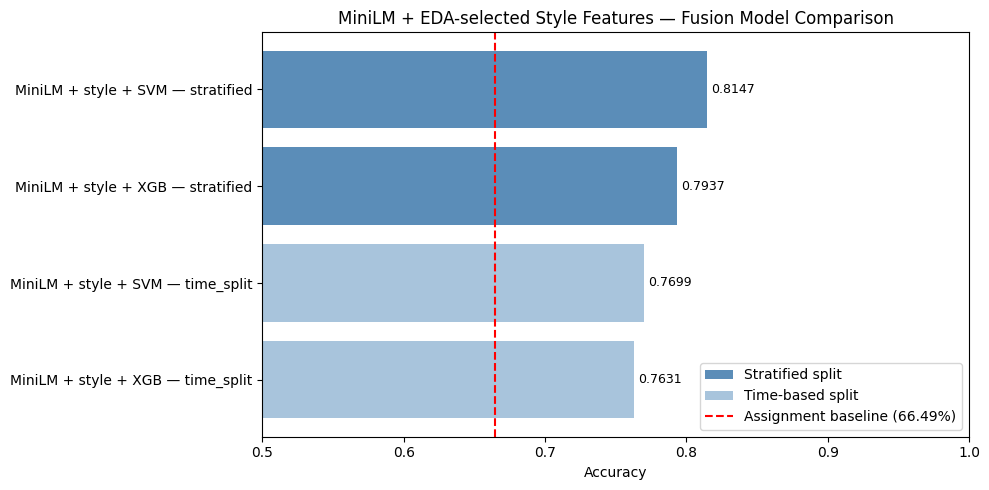

Plot saved.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# ── 1. LOAD PRECOMPUTED DATA ──────────────────────────────────────────────────
feature_df = pd.read_csv("../data/processed/style_features.csv", index_col=0)
feature_df["datetime_posted"] = pd.to_datetime(
    feature_df["datetime_posted"], utc=True, format="mixed"
)
embeddings = np.load("../data/processed/minilm_embeddings.npy")

print(f"Loaded {len(feature_df):,} rows | Fox%: {feature_df['is_fox'].mean():.2%}")
print(f"Embeddings shape: {embeddings.shape}")

# Attach embeddings to feature_df for aligned splitting
embedding_cols = [f"emb_{i}" for i in range(embeddings.shape[1])]
emb_df = pd.DataFrame(embeddings, columns=embedding_cols, index=feature_df.index)
full_df = pd.concat([feature_df, emb_df], axis=1)

STYLE_COLS = [
    "has_colon", "starts_with_number", "n_words", "char_count",
    "person_to_ent_ratio", "has_question", "allcaps_word_count"
]

# ── 2. SPLITS ────────────────────────────────────────────────────────────────

# -- Temporal --
df_dated   = full_df.dropna(subset=["datetime_posted"]).sort_values("datetime_posted")
df_undated = full_df[full_df["datetime_posted"].isna()]
split_idx  = int(len(df_dated) * 0.8)
train_dated, test_t = df_dated.iloc[:split_idx], df_dated.iloc[split_idx:]
train_t = pd.concat([train_dated, df_undated], ignore_index=False)

# -- Stratified --
train_s, test_s = train_test_split(
    full_df, test_size=0.2, random_state=42, stratify=full_df["is_fox"]
)

print(f"Temporal   — Train: {len(train_t):,} | Test: {len(test_t):,}")
print(f"             Test date range: {test_t['datetime_posted'].min().date()} -> {test_t['datetime_posted'].max().date()}")
print(f"Stratified — Train: {len(train_s):,} | Test: {len(test_s):,}")

# ── 3. EXTRACT FEATURE MATRICES ───────────────────────────────────────────────
# Embeddings
X_train_s_emb = train_s[embedding_cols].values
X_test_s_emb  = test_s[embedding_cols].values
X_train_t_emb = train_t[embedding_cols].values
X_test_t_emb  = test_t[embedding_cols].values

# Style features
X_train_s_style = train_s[STYLE_COLS].values
X_test_s_style  = test_s[STYLE_COLS].values
X_train_t_style = train_t[STYLE_COLS].values
X_test_t_style  = test_t[STYLE_COLS].values

# Labels
y_train_s = train_s["is_fox"].values
y_test_s  = test_s["is_fox"].values
y_train_t = train_t["is_fox"].values
y_test_t  = test_t["is_fox"].values

# ── 4. SCALE ─────────────────────────────────────────────────────────────────
# Embeddings — fit on train only
emb_scaler_s = StandardScaler()
X_train_s_emb_scaled = emb_scaler_s.fit_transform(X_train_s_emb)
X_test_s_emb_scaled  = emb_scaler_s.transform(X_test_s_emb)

emb_scaler_t = StandardScaler()
X_train_t_emb_scaled = emb_scaler_t.fit_transform(X_train_t_emb)
X_test_t_emb_scaled  = emb_scaler_t.transform(X_test_t_emb)

# Style features — fit on train only
style_scaler_s = StandardScaler()
X_train_s_style_scaled = style_scaler_s.fit_transform(X_train_s_style)
X_test_s_style_scaled  = style_scaler_s.transform(X_test_s_style)

style_scaler_t = StandardScaler()
X_train_t_style_scaled = style_scaler_t.fit_transform(X_train_t_style)
X_test_t_style_scaled  = style_scaler_t.transform(X_test_t_style)

# ── 5. FUSE ──────────────────────────────────────────────────────────────────
X_train_s_fusion = np.hstack([X_train_s_emb_scaled, X_train_s_style_scaled])
X_test_s_fusion  = np.hstack([X_test_s_emb_scaled,  X_test_s_style_scaled])
X_train_t_fusion = np.hstack([X_train_t_emb_scaled, X_train_t_style_scaled])
X_test_t_fusion  = np.hstack([X_test_t_emb_scaled,  X_test_t_style_scaled])

print(f"\nFusion feature shape: {X_train_s_fusion.shape}")  # should be (n, 391)

# ── 6. TRAIN & EVALUATE ──────────────────────────────────────────────────────
print("\nFitting SVM (stratified)...")
svm_s = SVC(kernel="rbf", C=1.0, random_state=42)
svm_s.fit(X_train_s_fusion, y_train_s)
acc_svm_s = accuracy_score(y_test_s, svm_s.predict(X_test_s_fusion))

print("Fitting SVM (temporal)...")
svm_t = SVC(kernel="rbf", C=1.0, random_state=42)
svm_t.fit(X_train_t_fusion, y_train_t)
acc_svm_t = accuracy_score(y_test_t, svm_t.predict(X_test_t_fusion))

print("Fitting XGBoost (stratified)...")
xgb_s = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric="logloss", random_state=42,
)
xgb_s.fit(X_train_s_fusion, y_train_s)
acc_xgb_s = accuracy_score(y_test_s, xgb_s.predict(X_test_s_fusion))

print("Fitting XGBoost (temporal)...")
xgb_t = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric="logloss", random_state=42,
)
xgb_t.fit(X_train_t_fusion, y_train_t)
acc_xgb_t = accuracy_score(y_test_t, xgb_t.predict(X_test_t_fusion))

# ── 7. RESULTS ───────────────────────────────────────────────────────────────
print("\n── Results ─────────────────────────────────────────────────")
print(f"  MiniLM + style + SVM (stratified): {acc_svm_s:.4f}")
print(f"  MiniLM + style + SVM (time split): {acc_svm_t:.4f}")
print(f"  SVM stratified/temporal gap:       {acc_svm_s - acc_svm_t:.4f}")
print(f"  MiniLM + style + XGB (stratified): {acc_xgb_s:.4f}")
print(f"  MiniLM + style + XGB (time split): {acc_xgb_t:.4f}")
print(f"  XGB stratified/temporal gap:       {acc_xgb_s - acc_xgb_t:.4f}")

# ── 8. PLOT ──────────────────────────────────────────────────────────────────
results = [
    {"label": "MiniLM + style + SVM — stratified", "accuracy": acc_svm_s, "split": "stratified"},
    {"label": "MiniLM + style + SVM — time_split", "accuracy": acc_svm_t, "split": "time_split"},
    {"label": "MiniLM + style + XGB — stratified", "accuracy": acc_xgb_s, "split": "stratified"},
    {"label": "MiniLM + style + XGB — time_split", "accuracy": acc_xgb_t, "split": "time_split"},
]

results_df = pd.DataFrame(results).sort_values("accuracy")
colors = ["#5b8db8" if s == "stratified" else "#a8c4dc" for s in results_df["split"]]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(results_df["label"], results_df["accuracy"], color=colors)
ax.axvline(0.6649, color="red", linestyle="--")
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("Accuracy")
ax.set_title("MiniLM + EDA-selected Style Features — Fusion Model Comparison")

legend_elements = [
    Patch(facecolor="#5b8db8", label="Stratified split"),
    Patch(facecolor="#a8c4dc", label="Time-based split"),
    plt.Line2D([0], [0], color="red", linestyle="--", label="Assignment baseline (66.49%)"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
# plt.savefig("fusion_eda_selected_results.png", dpi=150)
plt.show()
print("Plot saved.")